In [ ]:
"""
==========================================================================
                        LOUVAIN PASO A PASO
==========================================================================
Implementación de cero (sin usar networkx.louvain) del algoritmo de
Louvain, para ver cómo evoluciona la modularidad Q en tiempo real.

Sigue exactamente las notas de clase:

  * Modularidad   Q(C) = 1/2m * sum_{c} sum_{u,v in c} ( A_uv - k_u k_v / 2m )
  * Fase 1        cada nodo empieza solo; en orden aleatorio se mueve a la
                  comunidad vecina que maximiza  dQ = Q_despues - Q_antes;
                  se repite hasta que ningún nodo se mueve.
  * Fase 2        agregación: cada comunidad -> super-nodo con "lazo"
                  A_cc = 2 * (suma de pesos internos); los enlaces entre
                  comunidades se fusionan sumando pesos.
  * Se repiten Fase 1 + Fase 2 hasta que Q ya no mejora.
==========================================================================
"""

In [59]:
import argparse
import math
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

## Construcción red

In [60]:
EDGES_NOTAS = [
    (5, 6), (5, 8), (5,4),
    (6, 7), (6, 8),
    (7, 8),                   #comunidad A = {5,6,7,8}
    (0, 1), (0, 4), (1, 4),   #comunidad B = {0,1,4}
    (2, 3),                   #comunidad C = {2,3}
    (4, 3), (1, 2),            #enlaces B-C
    (4, 5),                    #enlaces A-B
]
POS_NOTAS = {
    7: (0.0, 0.5), 6: (1.0, 1.3), 8: (1.0, -0.3), 5: (2.0, 0.5),
    4: (3.2, 0.6), 1: (4.4, 0.6), 0: (3.8, 1.5), 3: (3.2, -0.7), 2: (4.4, -0.7),
}


def cargar_grafo(nombre):
    """Devuelve (G, pos, titulo). Los nodos son 0..n-1 (importante para indexar)."""
    if nombre == "karate":
        G = nx.karate_club_graph()
        pos = nx.spring_layout(G, seed=7)
        return G, pos, "Zachary Karate Club"
    G = nx.Graph()
    G.add_nodes_from(range(9))
    G.add_edges_from(EDGES_NOTAS)
    return G, POS_NOTAS, "Grafo de la hoja de clase"

## Definicion de Modularidad

In [61]:
def modularidad(A, comm):
    """
    Q = 1/2m * sum_{u,v} ( A_uv - k_u k_v / 2m ) * delta(c_u, c_v)
    """
    dos_m = A.sum()
    k = A.sum(axis=1)
    mismo = comm[:, None] == comm[None, :]
    return (A[mismo].sum() - np.outer(k, k)[mismo].sum() / dos_m) / dos_m

In [62]:
def louvain_traza(A0, seed=0):
    """
    Corre Louvain y devuelve una lista de frames para animar
    """
    rng = np.random.default_rng(seed)
    n0 = len(A0)
    A = A0.astype(float).copy()
    miembros = [[i] for i in range(n0)]   #nodos originales dentro de cada super-nodo
    etiqueta = np.arange(n0)              #id de color de cada super-nodo
    frames = []

    def etiquetas_originales(comm):
        out = np.empty(n0, dtype=int)
        for s, mem in enumerate(miembros):
            out[mem] = etiqueta[comm[s]]
        return out

    comm = np.arange(n0)
    q = modularidad(A, comm)
    frames.append(dict(kind="inicio", labels=etiquetas_originales(comm), Q=q, moved=[],
                       nivel=1, texto=f"Inicio: cada nodo es su propia comunidad  ->  Q = {q:.3f}"))
    nivel = 1

    while True:
        n = len(A)
        comm = np.arange(n)
        q = modularidad(A, comm)
        hubo_mejora = False
        barrido = 0

        #---------------- FASE 1: movimientos locales ----------------
        while True:
            barrido += 1
            cambio = False
            for i in rng.permutation(n):                      # orden aleatorio
                actual = comm[i]
                vecinas = {comm[j] for j in np.nonzero(A[i])[0] if j != i}
                mejor_c, mejor_q = actual, q
                for c in vecinas - {actual}:                  # probar cada comunidad vecina
                    prueba = comm.copy()
                    prueba[i] = c
                    qp = modularidad(A, prueba)
                    if qp > mejor_q + 1e-12:                  # estrictamente mejor
                        mejor_c, mejor_q = c, qp
                if mejor_c != actual:
                    dq = mejor_q - q
                    comm[i] = mejor_c
                    q = mejor_q
                    cambio = hubo_mejora = True
                    nodos = sorted(miembros[i])
                    frames.append(dict(
                        kind="mov", labels=etiquetas_originales(comm), Q=q, moved=nodos,
                        nivel=nivel,
                        texto=(f"Nivel {nivel} · Fase 1 · barrido {barrido}:  "
                               f"{'nodo' if len(nodos) == 1 else 'super-nodo'} {nodos} cambia de comunidad   "
                               f"ΔQ = {dq:+.3f}   ->   Q = {q:.3f}")))
            if not cambio:
                break

        if not hubo_mejora:
            break

        #---------------- FASE 2: agregación ----------------
        ids = np.unique(comm)
        P = (comm[:, None] == ids[None, :]).astype(float)     # matriz indicadora n x n_comunidades
        A_nueva = P.T @ A @ P                                  # suma de pesos; diagonal = 2*pesos internos
        mem_nuevos = [sum((miembros[s] for s in np.nonzero(comm == c)[0]), []) for c in ids]
        etiqueta = etiqueta[ids]
        A, miembros = A_nueva, mem_nuevos
        q_agr = modularidad(A, np.arange(len(A)))
        assert abs(q_agr - q) < 1e-9, "Q debería ser invariante a la agregación"
        frames.append(dict(
            kind="agrega", labels=etiquetas_originales(np.arange(len(A))), Q=q_agr, moved=[],
            nivel=nivel, super=dict(A=A.copy(), miembros=[list(m) for m in miembros]),
            texto=(f"Nivel {nivel} · Fase 2 · agregación:  {len(A)} super-nodos  "
                   f"(lazo = 2·Σw interno)   ->   Q sigue en {q_agr:.3f}")))
        nivel += 1
        if len(A) == 1:
            break

    frames.append(dict(kind="fin", labels=frames[-1]["labels"], Q=frames[-1]["Q"], moved=[],
                       nivel=nivel,
                       texto=f"FIN: Louvain converge con Q = {frames[-1]['Q']:.3f}  "
                             f"({len(set(frames[-1]['labels']))} comunidades)"))
    return frames

## Óptimo real y número de bell

Solo correrlo para redes pequeñas, pues con 15 nodos son mil millones de posibles particiones

In [63]:
#FUERZA BRUTA: números de Bell y óptimo exacto (solo grafos chicos)
def bell(n):
    """B_{n+1} = sum_k C(n,k) B_k  con B_0 = B_1 = 1."""
    B = [1, 1]
    for m in range(1, n):
        B.append(sum(math.comb(m, k) * B[k] for k in range(m + 1)))
    return B[n]


def todas_las_particiones(n):
    """Genera las B_n particiones de {0..n-1} como 'cadenas de crecimiento restringido'."""
    def rec(i, lab, m):
        if i == n:
            yield lab.copy()
            return
        for c in range(m + 1):
            lab.append(c)
            yield from rec(i + 1, lab, max(m, c + 1))
            lab.pop()
    yield from rec(0, [], 0)


def optimo_exacto(A):
    mejor_q, mejor = -np.inf, None
    for lab in todas_las_particiones(len(A)):
        q = modularidad(A, np.array(lab))
        if q > mejor_q:
            mejor_q, mejor = q, lab
    return mejor_q, mejor

## Visualización

In [64]:
CMAP = plt.get_cmap("tab20")


def dibujar_particion(ax, G, pos, labels, moved=()):
    ax.set_axis_off()
    colores = [CMAP(labels[v] % 20) for v in G.nodes]
    xy = np.array([pos[v] for v in G.nodes])
    ax.scatter(xy[:, 0], xy[:, 1], s=3300, c=colores, alpha=0.20, zorder=0, linewidths=0)  # "halo"
    intra = [(u, v) for u, v in G.edges if labels[u] == labels[v]]
    inter = [(u, v) for u, v in G.edges if labels[u] != labels[v]]
    nx.draw_networkx_edges(G, pos, edgelist=intra, ax=ax, width=2.6, edge_color="#222222")
    nx.draw_networkx_edges(G, pos, edgelist=inter, ax=ax, width=1.3, edge_color="#999999", style="dashed")
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores, node_size=650,
                           edgecolors=["red" if v in moved else "black" for v in G.nodes],
                           linewidths=[4.5 if v in moved else 1.0 for v in G.nodes])
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=10, font_weight="bold")
    ax.margins(0.12)


def dibujar_supergrafo(ax, pos, fr):
    ax.set_axis_off()
    B, mem = fr["super"]["A"], fr["super"]["miembros"]
    n = len(B)
    H = nx.Graph()
    H.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if B[i, j] > 0:
                H.add_edge(i, j, w=B[i, j])
    p = {i: np.mean([pos[v] for v in mem[i]], axis=0) for i in range(n)}
    col = [CMAP(fr["labels"][mem[i][0]] % 20) for i in range(n)]
    tam = 900 + 2600 * B.sum(axis=1) / B.sum(axis=1).max()
    if H.number_of_edges():
        nx.draw_networkx_edges(H, p, ax=ax, width=[1.5 + 1.5 * H[u][v]["w"] ** 0.5 for u, v in H.edges],
                               edge_color="#555555")
        nx.draw_networkx_edge_labels(H, p, ax=ax, font_size=11, font_color="firebrick",
                                     edge_labels={(u, v): f"{H[u][v]['w']:g}" for u, v in H.edges},
                                     bbox=dict(boxstyle="round", fc="white", ec="none", alpha=0.85))
    nx.draw_networkx_nodes(H, p, ax=ax, node_color=col, node_size=tam, edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(H, p, ax=ax, font_size=10, font_weight="bold",
                            labels={i: f"{{{','.join(map(str, sorted(mem[i])))}}}\nlazo={B[i, i]:g}" for i in range(n)})
    ax.margins(0.25)


def referencias_Q(frames):
    """Valores de Q 'de hoja': inicio y final de cada nivel (los que escribiste en las notas)."""
    refs = [(frames[0]["Q"], "inicio (singletons)")]
    for fr in frames:
        if fr["kind"] == "agrega":
            refs.append((fr["Q"], f"fin Fase 1 · nivel {fr['nivel']}"))
    return refs


def animar(G, pos, frames, titulo, q_opt=None, intervalo=1100):
    Qs = [f["Q"] for f in frames]
    refs = referencias_Q(frames)
    fig, (ax_g, ax_q) = plt.subplots(1, 2, figsize=(15, 7), gridspec_kw=dict(width_ratios=[1.2, 1]))
    fig.suptitle(f"Algoritmo de Louvain · {titulo}", fontsize=15, fontweight="bold")
    ymin, ymax = min(Qs) - 0.06, max(Qs + ([q_opt] if q_opt else [])) + 0.12
    leyenda = fig.text(0.5, 0.02, "", ha="center", fontsize=12,
                       bbox=dict(boxstyle="round", fc="lightyellow", ec="goldenrod"))

    def update(k):
        fr = frames[k]
        ax_g.clear()
        if fr["kind"] == "agrega":
            dibujar_supergrafo(ax_g, pos, fr)
            ax_g.set_title("Fase 2: SUPER-GRAFO (nodos = comunidades)", fontsize=12)
        else:
            dibujar_particion(ax_g, G, pos, fr["labels"], fr["moved"])
            ax_g.set_title("Red original (línea sólida = enlace dentro de comunidad)", fontsize=12)

        ax_q.clear()
        ax_q.set_xlim(-0.5, len(frames) - 0.5)
        ax_q.set_ylim(ymin, ymax)
        ax_q.set_xlabel("paso del algoritmo")
        ax_q.set_ylabel("modularidad  Q")
        ax_q.grid(alpha=0.3)
        for q, nombre in refs:                                   # niveles de la hoja
            ax_q.axhline(q, color="gray", ls=":", lw=1)
            ax_q.text(len(frames) - 0.6, q, f"{nombre}: {q:.3f}", ha="right", va="bottom", fontsize=9, color="dimgray")
        if q_opt is not None:
            ax_q.axhline(q_opt, color="green", ls="--", lw=1.5)
            ax_q.text(0, q_opt, f" óptimo global (fuerza bruta): {q_opt:.3f}", va="bottom", fontsize=9, color="green")
        for i in range(k + 1):                                   # marcas de agregación
            if frames[i]["kind"] == "agrega":
                ax_q.axvline(i, color="purple", ls="--", alpha=0.5)
                ax_q.text(i, ymin + 0.01, " agregación", rotation=90, va="bottom", color="purple", fontsize=9)
        ax_q.plot(range(k + 1), Qs[:k + 1], "-o", color="tab:blue", lw=2.5, ms=6)
        ax_q.plot([k], [Qs[k]], "o", color="red", ms=13, zorder=5)
        ax_q.annotate(f"Q = {Qs[k]:.3f}", (k, Qs[k]), textcoords="offset points", xytext=(10, -18),
                      fontsize=13, fontweight="bold", color="red")
        ax_q.set_title("Evolución de Q en tiempo real", fontsize=12)
        leyenda.set_text(fr["texto"])
        return []

    # cuántos 'ticks' se queda cada tipo de frame (para que dé tiempo de leer)
    secuencia = []
    for i, fr in enumerate(frames):
        secuencia += [i] * {"inicio": 2, "mov": 1, "agrega": 3, "fin": 4}[fr["kind"]]
    fig.subplots_adjust(bottom=0.12, top=0.91, wspace=0.15)
    anim = FuncAnimation(fig, update, frames=secuencia, interval=intervalo, repeat=False)
    return fig, anim


def figura_snapshots(G, pos, frames, titulo, ruta):
    """Las 'fotos' de la hoja: inicio -> fin de cada nivel."""
    fotos = [frames[0]] + [f for f in frames if f["kind"] == "agrega"]
    fig, axs = plt.subplots(1, len(fotos), figsize=(5.2 * len(fotos), 5))
    axs = np.atleast_1d(axs)
    for ax, fr in zip(axs, fotos):
        dibujar_particion(ax, G, pos, fr["labels"])
        nombre = "Inicio (singletons)" if fr["kind"] == "inicio" else f"Fin de la Fase 1 · nivel {fr['nivel']}"
        ax.set_title(f"{nombre}\nQ = {fr['Q']:.3f}", fontsize=13, fontweight="bold")
    fig.suptitle(f"{titulo}: así sube Q", fontsize=15)
    fig.tight_layout()
    fig.savefig(ruta, dpi=140)
    return fig

Grafo de la hoja de clase:  n = 9 nodos,  m = 12 enlaces
----------------------------------------------------------------------
Q(cada nodo solo)         = -0.118   (hoja: -0.118)
Q(todos en 1 comunidad)   = +0.000   (hoja: 0)
Espacio de búsqueda: B_9 = 21,147 particiones posibles
Óptimo exacto por fuerza bruta: Q* = 0.413  con  [[0, 1, 2, 3, 4], [5, 6, 7, 8]]
----------------------------------------------------------------------
Louvain (semilla 0):
  [inicio] Q = -0.118   Inicio: cada nodo es su propia comunidad  ->  Q = -0.118
  [   mov] Q = -0.062   Nivel 1 · Fase 1 · barrido 1:  nodo [4] cambia de comunidad   ΔQ = +0.056   ->   Q = -0.062
  [   mov] Q = -0.010   Nivel 1 · Fase 1 · barrido 1:  nodo [5] cambia de comunidad   ΔQ = +0.052   ->   Q = -0.010
  [   mov] Q = +0.059   Nivel 1 · Fase 1 · barrido 1:  nodo [2] cambia de comunidad   ΔQ = +0.069   ->   Q = 0.059
  [   mov] Q = +0.163   Nivel 1 · Fase 1 · barrido 1:  nodo [6] cambia de comunidad   ΔQ = +0.104   ->   Q = 0.163
  

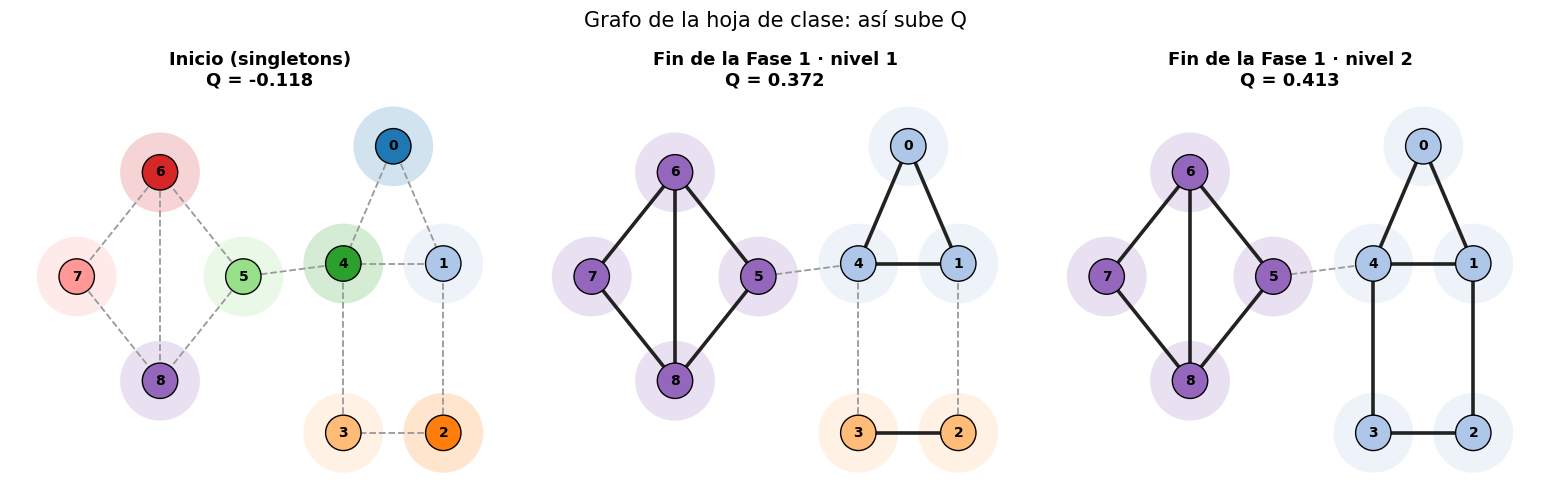

In [65]:
from IPython.display import HTML, display

plt.rcParams["animation.embed_limit"] = 200
SEMILLA_HOJA = 0

def correr(graph="notas", seed=None, intervalo=900, n_experimento=200, guardar_gif=False, out="salida_louvain"):
    """
    graph        : "notas" (grafo de la hoja) o "karate"
    seed         : semilla del orden aleatorio (None = la de la hoja / 0)
    intervalo    : milisegundos entre frames de la animación
    n_experimento: corridas para el histograma (0 = omitir)
    guardar_gif  : True -> además guarda un .gif en la carpeta `out`
    Devuelve un dict con G, pos, A, frames y anim para seguir explorando.
    """
    os.makedirs(out, exist_ok=True)
    G, pos, titulo = cargar_grafo(graph)
    A = nx.to_numpy_array(G, nodelist=range(G.number_of_nodes()))
    n, m = len(A), int(A.sum() / 2)
    seed = seed if seed is not None else (SEMILLA_HOJA if graph == "notas" else 0)

    print("=" * 70)
    print(f"{titulo}:  n = {n} nodos,  m = {m} enlaces")
    print("-" * 70)
    print(f"Q(cada nodo solo)         = {modularidad(A, np.arange(n)):+.3f}   (hoja: -0.118)")
    print(f"Q(todos en 1 comunidad)   = {modularidad(A, np.zeros(n, int)):+.3f}   (hoja: 0)")

    #---- fuerza bruta (solo si es factible) ----
    q_opt = None
    print(f"Espacio de búsqueda: B_{n} = {bell(n):,} particiones posibles")
    if n <= 10:
        q_opt, lab_opt = optimo_exacto(A)
        grupos = {}
        for v, c in enumerate(lab_opt):
            grupos.setdefault(c, []).append(v)
        print(f"Óptimo exacto por fuerza bruta: Q* = {q_opt:.3f}  con  {list(grupos.values())}")
    else:
        print("(demasiado grande para fuerza bruta: ¡por eso existe una heurística como Louvain!)")

    #---- Louvain con grabadora ----
    frames = louvain_traza(A, seed=seed)
    print("-" * 70)
    print(f"Louvain (semilla {seed}):")
    for fr in frames:
        print(f"  [{fr['kind']:>6}] Q = {fr['Q']:+.3f}   {fr['texto']}")
    print("=" * 70)
    try:   # validación contra la implementación de networkx
        com = nx.community.louvain_communities(G, seed=seed)
        print(f"networkx.louvain_communities -> Q = {nx.community.modularity(G, com):.3f}  (referencia)")
    except Exception:
        pass

    #---- 1) las "fotos" de la hoja ----
    fig_s = figura_snapshots(G, pos, frames, titulo, os.path.join(out, "louvain_snapshots.png"))
    display(fig_s)
    plt.close(fig_s)

    # ---- 2) animación EN LA CELDA (play / pausa / slider) ----
    fig_a, anim = animar(G, pos, frames, titulo, q_opt=q_opt, intervalo=intervalo)
    fig_a.set_dpi(80)
    if guardar_gif:
        ruta_gif = os.path.join(out, "louvain_animacion.gif")
        anim.save(ruta_gif, writer=PillowWriter(fps=1000 / intervalo), dpi=90)
        print(f"GIF guardado en: {ruta_gif}")
    html = anim.to_jshtml(default_mode="once")
    plt.close(fig_a)              # evita que se muestre también la figura estática
    display(HTML(html))

    return dict(G=G, pos=pos, A=A, frames=frames, anim=anim, q_opt=q_opt)


res = correr(graph="notas")
#res = correr(graph="karate", seed=3)
#res = correr(graph="notas", seed=5, intervalo=1500, guardar_gif=True)